DATASET LOADED
Rows : 150
Columns : 5

Duplicated Records : 3
Missing Values: 0
3 duplicate records removed.
Final Dataset Shape: (147, 5)

Statistical summary
       sepal_length  sepal_width  petal_length  petal_width
count    147.000000   147.000000    147.000000   147.000000
mean       5.856463     3.055782      3.780272     1.208844
std        0.829100     0.437009      1.759111     0.757874
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.400000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


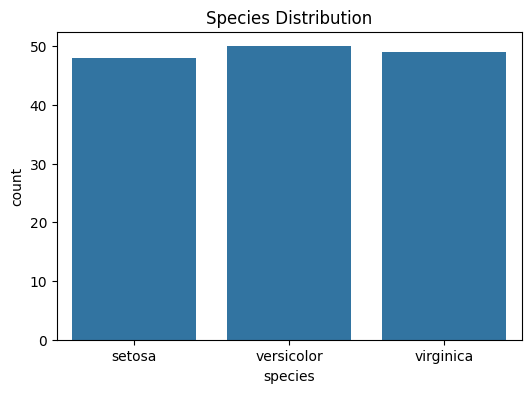

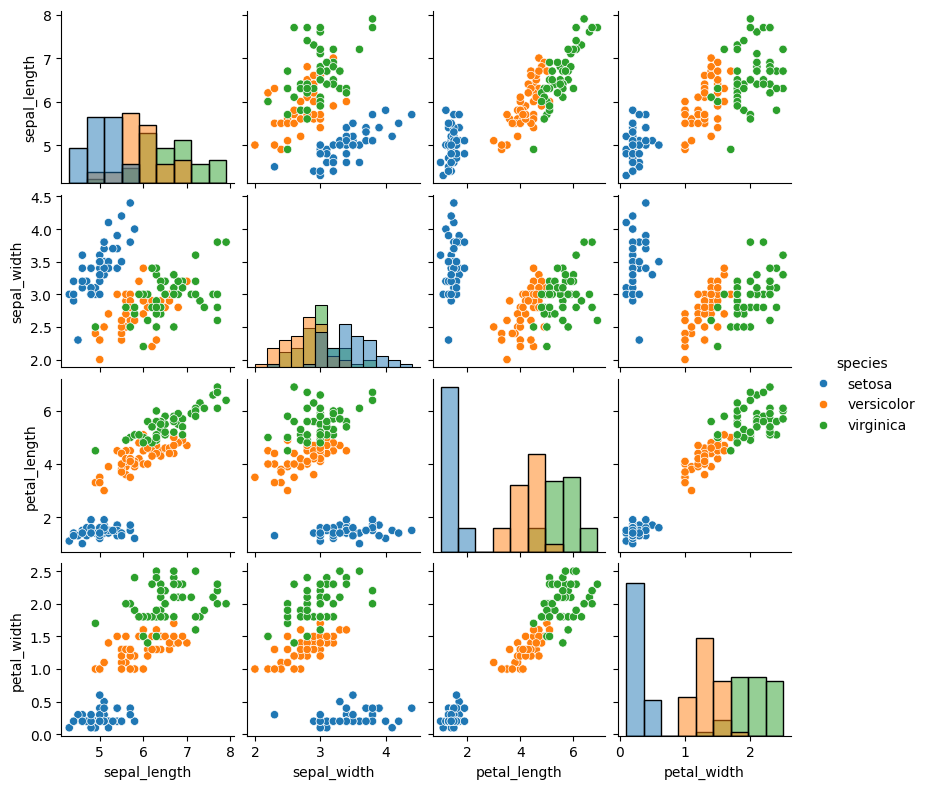

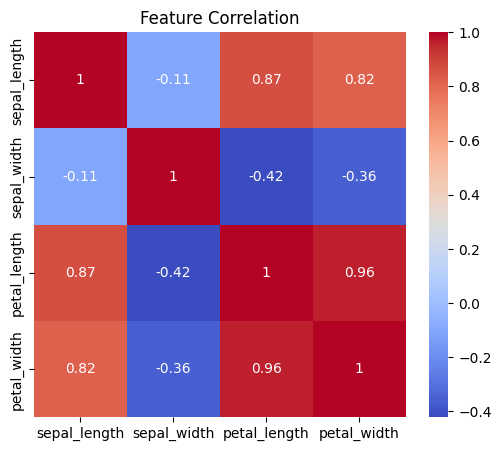


Species Percentage
species
versicolor    34.013605
virginica     33.333333
setosa        32.653061
Name: proportion, dtype: float64


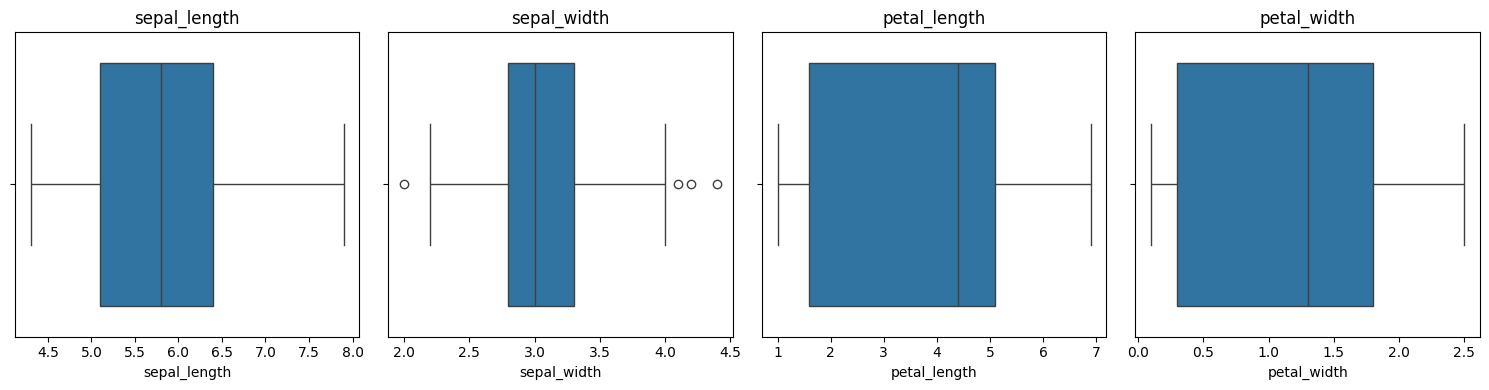


Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target:
species

Class Mapping
0 -> setosa
1 -> versicolor
2 -> virginica

Feature Matrix shape : (147, 4)
Target Vector Shape : (147,)

Train test split
X_train Shape: (117, 4)
X_test Shape: (30, 4)
y_train Shape: (117,)
y_test Shape: (30,)


MODEL COMPARISON
Logistic Regression       Accuracy = 0.9572 (+/- 0.0381)
Support Vector Machine    Accuracy = 0.9659 (+/- 0.0417)
Random Forest             Accuracy = 0.9656 (+/- 0.0324)

Model Ranking
                    Model  Accuracy
1  Support Vector Machine  0.965942
2           Random Forest  0.965580
0     Logistic Regression  0.957246


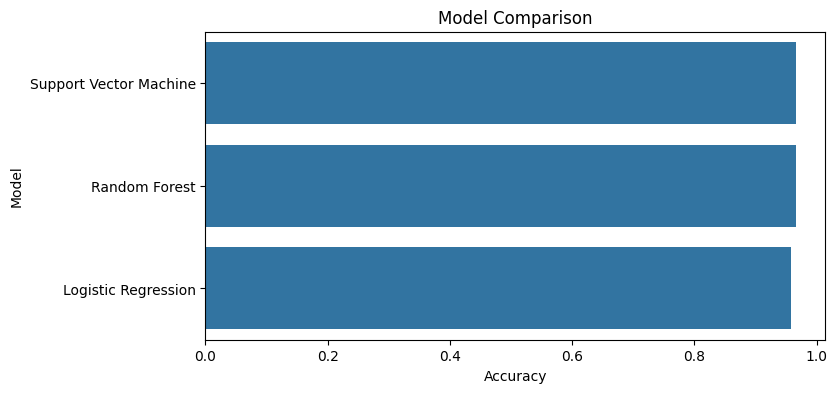


Performing Random Forest Tuning

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV score:
0.9485507246376812
Final Model Performance
Accuracy: 0.9667

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Cross Validation Results
CV Scores: [0.96666667 0.96666667 0.93103448 0.89655172 1.        ]
Mean Accuracy: 0.9522
Std Deviation: 0.0354

Cohen's Kappa Score: 0.9500


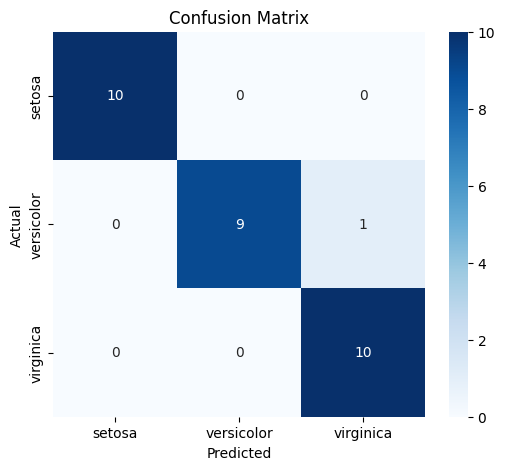


Feature Importance
        Feature  Importance  Importance (%)
2  petal_length    0.454710       45.471030
3   petal_width    0.413847       41.384694
0  sepal_length    0.116822       11.682202
1   sepal_width    0.014621        1.462073


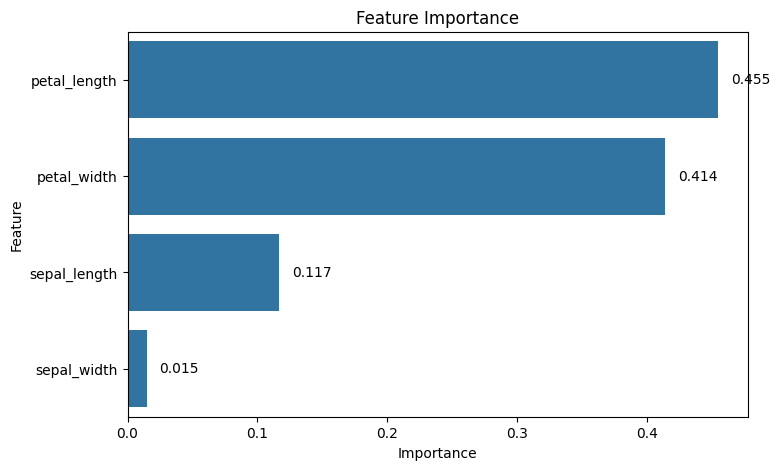


Model Saved Successfully

Sample prediction:

Predicted species: setosa

Class Probabilities:
setosa         : 100.00%
versicolor     : 0.00%
virginica      : 0.00%


In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Load Dataset

Data_URL  =  "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(Data_URL)
print("DATASET LOADED")

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()

#Data cleaning
duplicates = df.duplicated().sum()
print(f"Duplicated Records : {duplicates}")

print(f"Missing Values: {df.isnull().sum().sum()}")
if duplicates > 0:
  df.drop_duplicates(inplace=True)
  print(f"{duplicates} duplicate records removed.")
else:
  print("No duplicate records found.")
print(f"Final Dataset Shape: {df.shape}")
print()

#Data Analysis

print("Statistical summary")
print(df.describe())
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species')
plt.title("Species Distribution")
plt.show()

sns.pairplot(df, hue='species', diag_kind='hist', height=2)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation")
plt.show()

species_percent = (
    df["species"]
    .value_counts(normalize=True)
    * 100
)
print("\nSpecies Percentage")
print(species_percent)



fig, axes = plt.subplots(1, 4, figsize=(15,4))

for i, col in enumerate(df.columns[:-1]):
  sns.boxplot(
      x=df[col],
      ax=axes[i]
  )
  axes[i].set_title(col)
plt.tight_layout()
plt.show()

#Feature and target

X = df.drop("species", axis=1)
y = df["species"]
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("\nClass Mapping")
for i, cls in enumerate(encoder.classes_):
  print(f"{i} -> {cls}")

print(f"\nFeature Matrix shape : {X.shape}")
print(f"Target Vector Shape : {y_encoded.shape}")

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain test split")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")
print()

# MODEL COMPARISON

models = {

    "Logistic Regression":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression()
            )
        ]),

    "Support Vector Machine":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC()
            )
        ]),

    "Random Forest":

        Pipeline([
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=42
                )
            )
        ])
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

print("\nMODEL COMPARISON")


for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results[name] = scores.mean()

    print(
        f"{name:<25}"
        f" Accuracy = {scores.mean():.4f}"
        f" (+/- {scores.std():.4f})"
    )

comparison = pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Ranking")
print(comparison)

plt.figure(figsize=(8,4))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")
plt.show()

#Hyperparameter Tuning

print("\nPerforming Random Forest Tuning")
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth": [None, 5],
    "model__min_samples_split": [2, 5],

}
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1

)

grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

#Model evaluation

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Final Model Performance")

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

cv_scores = cross_val_score(
    best_model,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Results")
print(f"CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)

print(f"\nCohen's Kappa Score: {kappa:.4f}")

#Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_

)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Feature Importance

rf = best_model.named_steps["model"]
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance["Importance (%)"] = (
    importance["Importance"] * 100
)
importance =  importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
for i, v in enumerate(importance["Importance"]):
  ax.text(
      v + 0.01,
      i,
      f"{v:.3f}",
      va="center"
  )
plt.title("Feature Importance")
plt.show()

#Save model

joblib.dump(best_model, "iris_classifier.pkl")
joblib.dump(encoder, "label_encoder.pkl")
print("\nModel Saved Successfully")

#Sample prediction

def predict_species(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
    ):

       sample = pd.DataFrame({
           "sepal_length": [sepal_length],
           "sepal_width": [sepal_width],
           "petal_length": [petal_length],
           "petal_width": [petal_width]
    })
       pred = best_model.predict(sample)
       probs = best_model.predict_proba(sample)
       species = encoder.inverse_transform(pred)[0]

       print(f"\nPredicted species: {species}")
       print("\nClass Probabilities:")

       for cls, prob in zip(
           encoder.classes_,
           probs[0]
       ):
          print(f"{cls:<15}: {prob*100:.2f}%")

print("\nSample prediction:")
predict_species(
    5.1,
    3.5,
    1.4,
    0.2
)
